# Medical Prescription OCR — Kaggle Fine-Tuning

This notebook downloads your `splits.zip` from Google Drive, extracts it,
fine-tunes `microsoft/trocr-small-handwritten` on the line-level OCR data,
evaluates the resulting model, saves the best checkpoint to
`/kaggle/working/checkpoints/best_model`, and can optionally publish the
model to Hugging Face for a stable model URL.

Before you run it:
1. Turn Kaggle Internet **on** because the notebook downloads the dataset zip
   from Google Drive and may upload the final model to Hugging Face.
2. If you want a permanent Hugging Face model URL, add a Kaggle secret named
   `HF_TOKEN`.
3. The notebook is preconfigured to upload to
   `khedim/Medical-Prescription-OCR`.

If you skip the Hugging Face upload, Kaggle still preserves the zipped model
artifact in the notebook version output when you click `Save Version`.

In [24]:
%pip install -q -U transformers huggingface_hub jiwer tabulate gdown

Note: you may need to restart the kernel to use updated packages.


## 1. Imports, Download Configuration, And Runtime Setup

This cell configures the Google Drive download, Kaggle output folders, and
the recommended defaults for a 2xT4 run.

In [25]:
%matplotlib inline
import csv
import json
import math
import os
import random
import re
import shutil
import time
import warnings
import zipfile
from collections import defaultdict
from pathlib import Path

import gdown
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
from tqdm.auto import tqdm

import torch
from torch import nn
from torch.cuda.amp import GradScaler, autocast
from torch.optim import AdamW
from torch.utils.data import DataLoader, Dataset

from huggingface_hub import login, upload_folder
from transformers import (
    TrOCRProcessor,
    VisionEncoderDecoderModel,
    get_linear_schedule_with_warmup,
)

try:
    import jiwer
except ImportError:
    jiwer = None
    print('[WARN] jiwer is not installed. CER and WER will be unavailable.')

try:
    from kaggle_secrets import UserSecretsClient
except Exception:
    UserSecretsClient = None

warnings.filterwarnings('ignore', category=FutureWarning)
torch.backends.cudnn.benchmark = True

OUTPUT_ROOT = Path('/kaggle/working') if Path('/kaggle/working').exists() else Path('outputs')
CHECKPOINT_ROOT = OUTPUT_ROOT / 'checkpoints'
BEST_MODEL_DIR = CHECKPOINT_ROOT / 'best_model'
ARTIFACT_DIR = OUTPUT_ROOT / 'artifacts'
DOWNLOAD_ROOT = OUTPUT_ROOT / 'downloads'
DRIVE_EXTRACT_ROOT = DOWNLOAD_ROOT / 'splits_extracted'
DRIVE_ZIP_PATH = DOWNLOAD_ROOT / 'splits.zip'

CHECKPOINT_ROOT.mkdir(parents=True, exist_ok=True)
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
DOWNLOAD_ROOT.mkdir(parents=True, exist_ok=True)

VISIBLE_GPU_COUNT = max(1, torch.cuda.device_count())

SEED = 42
TRAIN_MODEL_NAME = 'microsoft/trocr-small-handwritten'
MAX_NEW_TOKENS = 128
FINAL_EVAL_NUM_BEAMS = 4
VALIDATION_NUM_BEAMS = 2 if VISIBLE_GPU_COUNT >= 2 else 4
TRAIN_EPOCHS = 6 if VISIBLE_GPU_COUNT >= 2 else 5
LEARNING_RATE = 4e-5 if VISIBLE_GPU_COUNT >= 2 else 5e-5
WEIGHT_DECAY = 0.01
WARMUP_RATIO = 0.06 if VISIBLE_GPU_COUNT >= 2 else 0.1
PER_DEVICE_BATCH_SIZE = 12 if VISIBLE_GPU_COUNT >= 2 else 8
GRADIENT_ACCUMULATION_STEPS = 1 if VISIBLE_GPU_COUNT >= 2 else 2
NUM_WORKERS = 4 if VISIBLE_GPU_COUNT >= 2 else 2
SOURCES = ('processed', 'augmented')

AUTO_DOWNLOAD_SPLITS = True
FORCE_REDOWNLOAD_SPLITS = False
FORCE_REEXTRACT_SPLITS = False
SPLITS_DRIVE_FILE_ID = '1_jf-U_7jn5yDgZfccy-3t1kSVfD_DLVM'
SPLITS_DRIVE_URL = f'https://drive.google.com/uc?id={SPLITS_DRIVE_FILE_ID}'

HF_REPO_ID = 'khedim/Medical-Prescription-OCR'
HF_PRIVATE_REPO = False


def seed_everything(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def strip_ocr(text):
    text = text or ''
    return re.sub(r'\s+', ' ', text.replace('<s_ocr>', '').replace('</s>', '')).strip()


def rank_split_candidates(search_roots):
    candidates = []
    seen = set()
    for root in search_roots:
        root = Path(root)
        if not root.exists():
            continue
        for csv_path in root.rglob('image_annotations.csv'):
            parent = csv_path.parent.resolve()
            if parent in seen:
                continue
            seen.add(parent)
            score = 0
            if (parent / 'processed').exists():
                score += 4
            if (parent / 'augmented').exists():
                score += 4
            if (parent / 'annotations').exists():
                score += 4
            if 'split' in str(parent).lower():
                score += 2
            candidates.append((score, len(str(parent)), parent))
    candidates.sort(key=lambda item: (-item[0], item[1]))
    return candidates


def ensure_drive_splits_extracted():
    if FORCE_REDOWNLOAD_SPLITS and DRIVE_ZIP_PATH.exists():
        DRIVE_ZIP_PATH.unlink()
    if FORCE_REEXTRACT_SPLITS and DRIVE_EXTRACT_ROOT.exists():
        shutil.rmtree(DRIVE_EXTRACT_ROOT)

    if any(DRIVE_EXTRACT_ROOT.rglob('image_annotations.csv')):
        return

    DRIVE_EXTRACT_ROOT.mkdir(parents=True, exist_ok=True)

    if not DRIVE_ZIP_PATH.exists():
        print(f'Downloading splits zip from Google Drive to: {DRIVE_ZIP_PATH}')
        downloaded = None
        try:
            downloaded = gdown.download(id=SPLITS_DRIVE_FILE_ID, output=str(DRIVE_ZIP_PATH), quiet=False)
        except Exception as exc:
            print(f'[WARN] Download by file id failed: {exc}')
        if not downloaded:
            downloaded = gdown.download(url=SPLITS_DRIVE_URL, output=str(DRIVE_ZIP_PATH), quiet=False, fuzzy=True)
        if not downloaded or not DRIVE_ZIP_PATH.exists():
            raise RuntimeError(
                'Failed to download splits.zip from Google Drive. '
                'Make sure Kaggle Internet is enabled.'
            )

    if not zipfile.is_zipfile(DRIVE_ZIP_PATH):
        raise ValueError(
            f'{DRIVE_ZIP_PATH} is not a valid zip file. '
            'Re-run with FORCE_REDOWNLOAD_SPLITS=True if the download was interrupted.'
        )

    if not any(DRIVE_EXTRACT_ROOT.iterdir()):
        print(f'Extracting {DRIVE_ZIP_PATH} to: {DRIVE_EXTRACT_ROOT}')
        with zipfile.ZipFile(DRIVE_ZIP_PATH, 'r') as archive:
            archive.extractall(DRIVE_EXTRACT_ROOT)
    elif not any(DRIVE_EXTRACT_ROOT.rglob('image_annotations.csv')):
        print(f'Re-extracting {DRIVE_ZIP_PATH} to repair missing files in: {DRIVE_EXTRACT_ROOT}')
        with zipfile.ZipFile(DRIVE_ZIP_PATH, 'r') as archive:
            archive.extractall(DRIVE_EXTRACT_ROOT)


def discover_splits_root(auto_download=AUTO_DOWNLOAD_SPLITS):
    search_roots = [Path('/kaggle/input'), DRIVE_EXTRACT_ROOT, OUTPUT_ROOT, Path('.')]
    candidates = rank_split_candidates(search_roots)
    if not candidates and auto_download:
        ensure_drive_splits_extracted()
        candidates = rank_split_candidates(search_roots)
    if not candidates:
        raise FileNotFoundError(
            'Could not find image_annotations.csv after checking Kaggle inputs and the Google Drive download.'
        )
    best = candidates[0][2]
    return best, [str(item[2]) for item in candidates]


def resolve_split_path(path_text, splits_root):
    raw = str(path_text).replace('\\', '/')
    if os.path.isabs(raw) and os.path.exists(raw):
        return raw
    parts = [part for part in raw.split('/') if part not in ('', '.')]
    if len(parts) >= 2 and parts[0] == 'data' and parts[1] == 'splits':
        parts = parts[2:]
    if parts and parts[0] == 'splits':
        parts = parts[1:]
    return str(splits_root.joinpath(*parts))


seed_everything()
SPLITS_ROOT, DISCOVERED_SPLIT_ROOTS = discover_splits_root(auto_download=AUTO_DOWNLOAD_SPLITS)
MAPPING_CSV = SPLITS_ROOT / 'image_annotations.csv'

print(f'Outputs                 : {OUTPUT_ROOT}')
print(f'Download root           : {DOWNLOAD_ROOT}')
print(f'Drive zip path          : {DRIVE_ZIP_PATH}')
print(f'Splits root             : {SPLITS_ROOT}')
print(f'Mapping CSV             : {MAPPING_CSV}')
print(f'Visible GPUs            : {VISIBLE_GPU_COUNT}')
print(f'Per-device batch size   : {PER_DEVICE_BATCH_SIZE}')
print(f'Gradient accumulation   : {GRADIENT_ACCUMULATION_STEPS}')
print(f'Train epochs            : {TRAIN_EPOCHS}')
print(f'Learning rate           : {LEARNING_RATE}')
print(f'Validation beams        : {VALIDATION_NUM_BEAMS}')
print(f'Final eval beams        : {FINAL_EVAL_NUM_BEAMS}')
print(f'Discovered roots        : {DISCOVERED_SPLIT_ROOTS[:5]}')

Outputs                 : /kaggle/working
Download root           : /kaggle/working/downloads
Drive zip path          : /kaggle/working/downloads/splits.zip
Splits root             : /kaggle/working/downloads/splits_extracted/splits
Mapping CSV             : /kaggle/working/downloads/splits_extracted/splits/image_annotations.csv
Visible GPUs            : 2
Per-device batch size   : 12
Gradient accumulation   : 1
Train epochs            : 6
Learning rate           : 4e-05
Validation beams        : 2
Final eval beams        : 4
Discovered roots        : ['/kaggle/working/downloads/splits_extracted/splits']


## 2. Dataset, Model, And Utility Helpers

The training data is already line-segmented, so the notebook reads the line
crops directly from `image_annotations.csv` and groups splits by
`prescription_id` to avoid leakage across train, validation, and test.

In [26]:
def load_line_samples(csv_path=MAPPING_CSV, sources=SOURCES):
    samples = []
    missing_files = 0
    with open(csv_path, encoding='utf-8') as handle:
        reader = csv.DictReader(handle)
        for row in reader:
            if row.get('source') not in sources:
                continue
            origin_id = row['origin_id']
            image_path = resolve_split_path(row['image_path'], SPLITS_ROOT)
            if not os.path.isfile(image_path):
                missing_files += 1
                continue
            samples.append(
                {
                    'id': origin_id,
                    'prescription_id': origin_id.split('/', 1)[0],
                    'origin_id': origin_id,
                    'image_path': image_path,
                    'annotation_path': resolve_split_path(row['annotation_path'], SPLITS_ROOT),
                    'source': row['source'],
                    'text': row.get('ground_truth_clean') or strip_ocr(row.get('ground_truth_raw')),
                }
            )
    if not samples:
        raise ValueError('No usable line samples were found in image_annotations.csv.')
    if missing_files:
        print(f'[WARN] Skipped {missing_files} rows because the image file was missing.')
    samples.sort(key=lambda sample: (sample['prescription_id'], sample['origin_id']))
    return samples


def make_splits(samples, train_ratio=0.8, val_ratio=0.1, seed=SEED):
    by_prescription = defaultdict(list)
    for sample in samples:
        by_prescription[sample['prescription_id']].append(sample)

    prescription_ids = sorted(by_prescription)
    random.Random(seed).shuffle(prescription_ids)

    total = len(prescription_ids)
    train_cutoff = int(total * train_ratio)
    val_cutoff = int(total * (train_ratio + val_ratio))

    train_ids = prescription_ids[:train_cutoff]
    val_ids = prescription_ids[train_cutoff:val_cutoff]
    test_ids = prescription_ids[val_cutoff:]

    train = [sample for pid in train_ids for sample in by_prescription[pid]]
    val = [sample for pid in val_ids for sample in by_prescription[pid]]
    test = [sample for pid in test_ids for sample in by_prescription[pid]]
    return train, val, test


class PrescriptionLineDataset(Dataset):
    def __init__(self, samples, processor, max_length=MAX_NEW_TOKENS):
        self.samples = samples
        self.processor = processor
        self.max_length = max_length

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, index):
        sample = self.samples[index]
        image = Image.open(sample['image_path']).convert('RGB')
        pixel_values = self.processor(images=image, return_tensors='pt').pixel_values.squeeze(0)
        labels = self.processor.tokenizer(
            sample['text'],
            padding='max_length',
            truncation=True,
            max_length=self.max_length,
            return_tensors='pt',
        ).input_ids.squeeze(0)
        labels[labels == self.processor.tokenizer.pad_token_id] = -100
        return {
            'pixel_values': pixel_values,
            'labels': labels,
            'text': sample['text'],
            'origin_id': sample['origin_id'],
            'prescription_id': sample['prescription_id'],
        }


class PrescriptionOCR(nn.Module):
    def __init__(self, model_name=TRAIN_MODEL_NAME):
        super().__init__()
        self.processor = TrOCRProcessor.from_pretrained(model_name)
        self.model = VisionEncoderDecoderModel.from_pretrained(model_name)
        self.model.config.decoder_start_token_id = self.processor.tokenizer.cls_token_id
        self.model.config.pad_token_id = self.processor.tokenizer.pad_token_id
        self.model.config.eos_token_id = self.processor.tokenizer.sep_token_id
        self.model.config.max_length = None
        self.model.generation_config.max_new_tokens = MAX_NEW_TOKENS
        self.model.generation_config.num_beams = FINAL_EVAL_NUM_BEAMS

    def forward(self, pixel_values, labels=None):
        return self.model(pixel_values=pixel_values, labels=labels)

    @torch.no_grad()
    def generate(self, pixel_values, max_new_tokens=MAX_NEW_TOKENS, num_beams=FINAL_EVAL_NUM_BEAMS):
        output_ids = self.model.generate(
            pixel_values,
            max_new_tokens=max_new_tokens,
            num_beams=num_beams,
        )
        return self.processor.batch_decode(output_ids, skip_special_tokens=True)

    def save(self, path):
        path = Path(path)
        path.mkdir(parents=True, exist_ok=True)
        self.model.generation_config.num_beams = FINAL_EVAL_NUM_BEAMS
        self.model.generation_config.max_new_tokens = MAX_NEW_TOKENS
        self.model.save_pretrained(path)
        self.processor.save_pretrained(path)

    @classmethod
    def load(cls, path):
        obj = cls.__new__(cls)
        nn.Module.__init__(obj)
        obj.processor = TrOCRProcessor.from_pretrained(path)
        obj.model = VisionEncoderDecoderModel.from_pretrained(path)
        obj.model.config.max_length = None
        obj.model.generation_config.max_new_tokens = MAX_NEW_TOKENS
        obj.model.generation_config.num_beams = FINAL_EVAL_NUM_BEAMS
        return obj


def unwrap_model(model):
    return model.module if isinstance(model, nn.DataParallel) else model


def compute_cer(predictions, references):
    if jiwer is None:
        return float('nan')
    return float(jiwer.cer(references, predictions))


def compute_word_accuracy(predictions, references):
    if jiwer is None:
        return float('nan')
    return float(1.0 - jiwer.wer(references, predictions))


@torch.no_grad()
def decode_loader(model_wrapper, data_loader, processor, device, desc, num_beams):
    model_wrapper.eval()
    model_ref = unwrap_model(model_wrapper)
    predictions, references = [], []
    for batch in tqdm(data_loader, desc=desc):
        pixel_values = batch['pixel_values'].to(device, non_blocking=True)
        output_ids = model_ref.model.generate(
            pixel_values,
            max_new_tokens=MAX_NEW_TOKENS,
            num_beams=num_beams,
        )
        predictions.extend(processor.batch_decode(output_ids, skip_special_tokens=True))
        references.extend(batch['text'])
    return predictions, references


def format_metric(value):
    if value is None:
        return 'n/a'
    if isinstance(value, float) and math.isnan(value):
        return 'n/a'
    return f'{value:.4f}'


def zip_directory(source_dir, zip_path):
    source_dir = Path(source_dir)
    zip_path = Path(zip_path)
    with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as archive:
        for file_path in sorted(source_dir.rglob('*')):
            if file_path.is_file():
                archive.write(file_path, file_path.relative_to(source_dir.parent))
    return zip_path


def build_model_card(summary):
    return f"""---
library_name: transformers
pipeline_tag: image-to-text
tags:
- ocr
- trocr
- handwriting
- medical
---
# Medical Prescription OCR TrOCR Small

This model was fine-tuned in Kaggle on line-level medical prescription crops
exported through `data/splits/image_annotations.csv`.

## Base model
- `{summary['train_model_name']}`

## Dataset summary
- Splits root: `{summary['splits_root']}`
- Train lines: `{summary['train_lines']}`
- Validation lines: `{summary['val_lines']}`
- Test lines: `{summary['test_lines']}`

## Training setup
- Epochs: `{summary['epochs']}`
- Effective batch size: `{summary['effective_batch_size']}`
- Learning rate: `{summary['learning_rate']}`
- Weight decay: `{summary['weight_decay']}`
- GPUs seen: `{summary['gpu_count']}`
- Validation beams: `{summary['validation_num_beams']}`
- Final eval beams: `{summary['final_eval_num_beams']}`

## Metrics
- Best validation CER: `{format_metric(summary['best_val_cer'])}`
- Test line CER: `{format_metric(summary['test_line_cer'])}`
- Test full-prescription CER: `{format_metric(summary['test_full_cer'])}`
- Test line word accuracy: `{format_metric(summary['test_line_word_accuracy'])}`
- Test full-prescription word accuracy: `{format_metric(summary['test_full_word_accuracy'])}`
"""


def get_secret(name):
    if UserSecretsClient is not None:
        try:
            return UserSecretsClient().get_secret(name)
        except Exception:
            pass
    return os.getenv(name)

## 3. Load The Line-Level Dataset

This notebook expects the line crops generated from your exported `splits`
folder, which is automatically downloaded from Google Drive when needed.

Total line samples     : 25293
Processed line samples : 8431
Augmented line samples : 16862
Distinct prescriptions : 1000
Train / Val / Test     : 20250 / 2526 / 2517


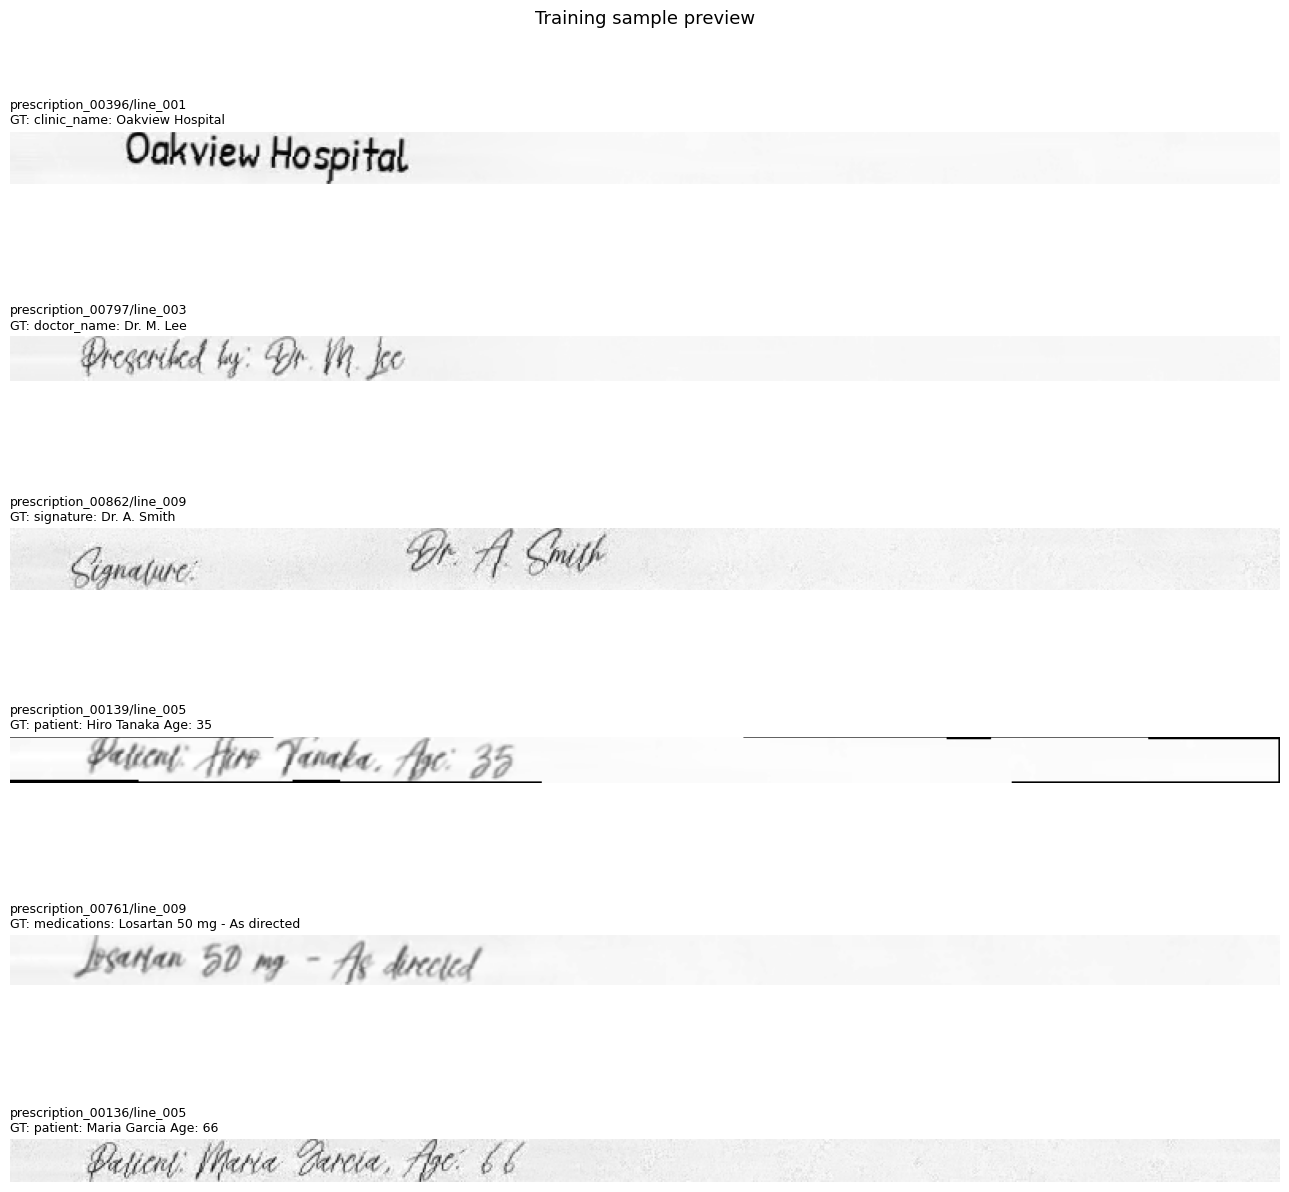

In [27]:
line_samples = load_line_samples(MAPPING_CSV, sources=SOURCES)
train_samples, val_samples, test_samples = make_splits(line_samples)

processed_count = sum(sample['source'] == 'processed' for sample in line_samples)
augmented_count = len(line_samples) - processed_count
distinct_prescriptions = len({sample['prescription_id'] for sample in line_samples})

print(f'Total line samples     : {len(line_samples)}')
print(f'Processed line samples : {processed_count}')
print(f'Augmented line samples : {augmented_count}')
print(f'Distinct prescriptions : {distinct_prescriptions}')
print(f'Train / Val / Test     : {len(train_samples)} / {len(val_samples)} / {len(test_samples)}')

preview_samples = random.sample(train_samples, min(6, len(train_samples)))
if preview_samples:
    fig, axes = plt.subplots(len(preview_samples), 1, figsize=(13, max(3, 2.2 * len(preview_samples))))
    if len(preview_samples) == 1:
        axes = [axes]

    for ax, sample in zip(axes, preview_samples):
        image = Image.open(sample['image_path']).convert('RGB')
        ax.imshow(np.array(image))
        ax.set_title(f"{sample['origin_id']}\nGT: {sample['text'][:120]}", loc='left', fontsize=9)
        ax.axis('off')

    plt.suptitle('Training sample preview', fontsize=13)
    plt.tight_layout()
    plt.show()
else:
    print('No training preview available because the training split is empty.')

## 4. DataLoaders

These defaults are tuned for throughput on 2xT4. If you hit CUDA OOM on your
run, reduce `PER_DEVICE_BATCH_SIZE` from `12` to `10` or `8`.

In [28]:
gpu_count = max(1, torch.cuda.device_count())
global_batch_size = PER_DEVICE_BATCH_SIZE * gpu_count
effective_batch_size = global_batch_size * GRADIENT_ACCUMULATION_STEPS

processor = TrOCRProcessor.from_pretrained(TRAIN_MODEL_NAME)
train_dataset = PrescriptionLineDataset(train_samples, processor, max_length=MAX_NEW_TOKENS)
val_dataset = PrescriptionLineDataset(val_samples, processor, max_length=MAX_NEW_TOKENS)
test_dataset = PrescriptionLineDataset(test_samples, processor, max_length=MAX_NEW_TOKENS)

loader_kwargs = {
    'num_workers': NUM_WORKERS,
    'pin_memory': torch.cuda.is_available(),
}
if NUM_WORKERS > 0:
    loader_kwargs['persistent_workers'] = True

train_loader = DataLoader(train_dataset, batch_size=global_batch_size, shuffle=True, **loader_kwargs)
val_loader = DataLoader(val_dataset, batch_size=global_batch_size, shuffle=False, **loader_kwargs)
test_loader = DataLoader(test_dataset, batch_size=global_batch_size, shuffle=False, **loader_kwargs)

batch = next(iter(train_loader))
print(f'GPUs visible         : {gpu_count}')
print(f'Global batch size    : {global_batch_size}')
print(f'Effective batch size : {effective_batch_size}')
print(f'pixel_values shape   : {tuple(batch["pixel_values"].shape)}')
print(f'labels shape         : {tuple(batch["labels"].shape)}')

GPUs visible         : 2
Global batch size    : 24
Effective batch size : 24
pixel_values shape   : (24, 3, 384, 384)
labels shape         : (24, 128)


## 5. Model Setup

The training model is `trocr-small-handwritten`, which is the safer option
for Kaggle VRAM while still giving strong OCR quality on the line crops.

In [29]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device            : {device}')
print(f'CUDA available    : {torch.cuda.is_available()}')
print(f'CUDA device count : {torch.cuda.device_count()}')
if torch.cuda.is_available():
    for gpu_index in range(torch.cuda.device_count()):
        print(f'GPU {gpu_index}            : {torch.cuda.get_device_name(gpu_index)}')

ocr = PrescriptionOCR(TRAIN_MODEL_NAME).to(device)
if torch.cuda.device_count() > 1:
    ocr = nn.DataParallel(ocr)

model_ref = unwrap_model(ocr)
trainable_params = sum(param.numel() for param in model_ref.parameters() if param.requires_grad)
print(f'Trainable parameters: {trainable_params:,}')
print(f'Model wrapper       : {type(ocr).__name__}')

Device            : cuda
CUDA available    : True
CUDA device count : 2
GPU 0            : Tesla T4
GPU 1            : Tesla T4


Loading weights:   0%|          | 0/360 [00:00<?, ?it/s]

[transformers] VisionEncoderDecoderModel LOAD REPORT from: microsoft/trocr-small-handwritten
Key                         | Status  | 
----------------------------+---------+-
encoder.pooler.dense.weight | MISSING | 
encoder.pooler.dense.bias   | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Trainable parameters: 61,596,672
Model wrapper       : DataParallel


## 6. Fine-Tuning Loop

The notebook tracks training loss and validation metrics every epoch. The
best checkpoint by validation CER is written to `BEST_MODEL_DIR`.

In [30]:
optimizer = AdamW(model_ref.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
steps_per_epoch = math.ceil(len(train_loader) / GRADIENT_ACCUMULATION_STEPS)
total_optimizer_steps = TRAIN_EPOCHS * steps_per_epoch
warmup_steps = max(1, int(total_optimizer_steps * WARMUP_RATIO))
scheduler = get_linear_schedule_with_warmup(optimizer, warmup_steps, total_optimizer_steps)

use_fp16 = device.type == 'cuda'
scaler = GradScaler(enabled=use_fp16)

train_losses = []
val_cers = []
val_word_accuracies = []
batch_losses = []
lr_history = []
best_cer = float('inf')
best_epoch = None

optimizer.zero_grad(set_to_none=True)

for epoch in range(1, TRAIN_EPOCHS + 1):
    ocr.train()
    running_loss = 0.0
    progress = tqdm(enumerate(train_loader, start=1), total=len(train_loader), desc=f'Epoch {epoch}/{TRAIN_EPOCHS}')

    for step, batch in progress:
        pixel_values = batch['pixel_values'].to(device, non_blocking=True)
        labels = batch['labels'].to(device, non_blocking=True)

        with autocast(enabled=use_fp16):
            outputs = ocr(pixel_values, labels=labels)
            loss = outputs.loss
            if loss.ndim > 0:
                loss = loss.mean()
            loss = loss / GRADIENT_ACCUMULATION_STEPS

        scaler.scale(loss).backward()
        raw_loss = loss.item() * GRADIENT_ACCUMULATION_STEPS
        running_loss += raw_loss
        batch_losses.append(raw_loss)

        should_step = (step % GRADIENT_ACCUMULATION_STEPS == 0) or (step == len(train_loader))
        if should_step:
            scaler.unscale_(optimizer)
            nn.utils.clip_grad_norm_(model_ref.parameters(), 1.0)
            scale_before = scaler.get_scale()
            scaler.step(optimizer)
            scaler.update()
            if scaler.get_scale() == scale_before:
                scheduler.step()
            optimizer.zero_grad(set_to_none=True)
            lr_history.append(scheduler.get_last_lr()[0])

        progress.set_postfix(loss=f'{raw_loss:.4f}')

    average_train_loss = running_loss / max(1, len(train_loader))
    train_losses.append(average_train_loss)

    val_predictions, val_references = decode_loader(
        ocr,
        val_loader,
        processor,
        device,
        desc=f'Validate {epoch}',
        num_beams=VALIDATION_NUM_BEAMS,
    )
    validation_cer = compute_cer(val_predictions, val_references)
    validation_word_accuracy = compute_word_accuracy(val_predictions, val_references)
    val_cers.append(validation_cer)
    val_word_accuracies.append(validation_word_accuracy)

    if not math.isnan(validation_cer) and validation_cer < best_cer:
        best_cer = validation_cer
        best_epoch = epoch
        model_ref.save(BEST_MODEL_DIR)
        print(f'  ★ New best checkpoint saved to {BEST_MODEL_DIR} (val CER={validation_cer:.4f})')

    print(
        f'  Epoch {epoch}: '
        f'loss={average_train_loss:.4f} | '
        f'val CER={format_metric(validation_cer)} | '
        f'val word acc={format_metric(validation_word_accuracy)}'
    )

if not BEST_MODEL_DIR.exists():
    model_ref.save(BEST_MODEL_DIR)
    print(f'[INFO] CER was unavailable, so the last checkpoint was saved to {BEST_MODEL_DIR}.')

Epoch 1/6:   0%|          | 0/844 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Validate 1:   0%|          | 0/106 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  ★ New best checkpoint saved to /kaggle/working/checkpoints/best_model (val CER=0.0422)
  Epoch 1: loss=1.1850 | val CER=0.0422 | val word acc=0.9426


...

Validate 5:   0%|          | 0/106 [00:00<?, ?it/s]

  Epoch 5: loss=0.0095 | val CER=0.0057 | val word acc=0.9930


Epoch 6/6:   0%|          | 0/844 [00:00<?, ?it/s]

Validate 6:   0%|          | 0/106 [00:00<?, ?it/s]

  Epoch 6: loss=0.0052 | val CER=0.0057 | val word acc=0.9928


## 7. Training Curves

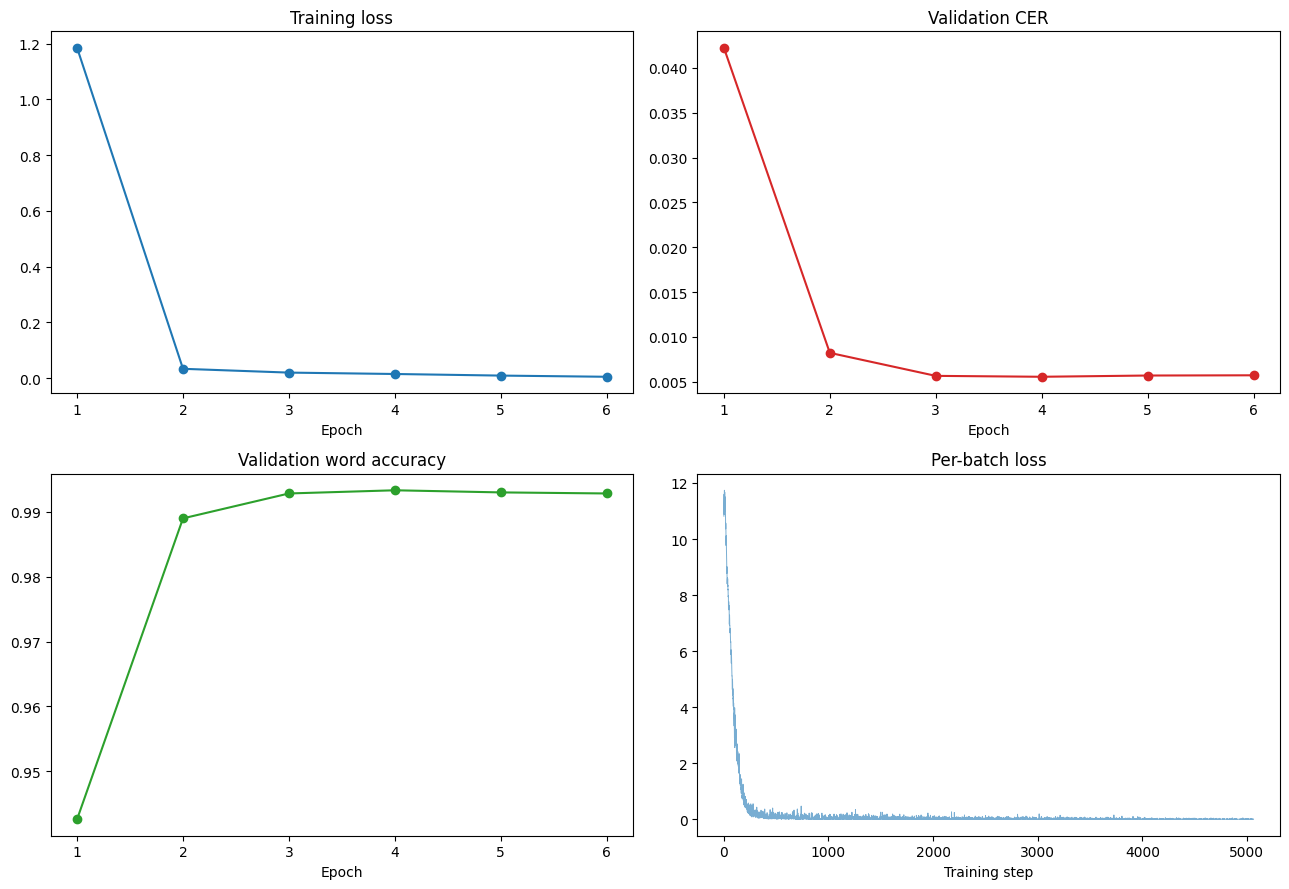

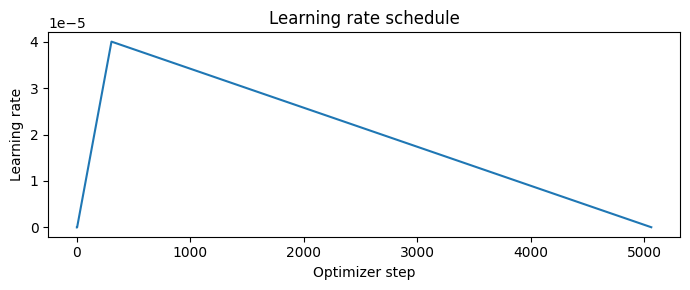

In [31]:
figure, axes = plt.subplots(2, 2, figsize=(13, 9))
epoch_axis = range(1, len(train_losses) + 1)

axes[0, 0].plot(epoch_axis, train_losses, marker='o')
axes[0, 0].set_title('Training loss')
axes[0, 0].set_xlabel('Epoch')

axes[0, 1].plot(epoch_axis, val_cers, marker='o', color='tab:red')
axes[0, 1].set_title('Validation CER')
axes[0, 1].set_xlabel('Epoch')

axes[1, 0].plot(epoch_axis, val_word_accuracies, marker='o', color='tab:green')
axes[1, 0].set_title('Validation word accuracy')
axes[1, 0].set_xlabel('Epoch')

axes[1, 1].plot(batch_losses, alpha=0.6, linewidth=0.7)
axes[1, 1].set_title('Per-batch loss')
axes[1, 1].set_xlabel('Training step')

plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 3))
plt.plot(lr_history)
plt.title('Learning rate schedule')
plt.xlabel('Optimizer step')
plt.ylabel('Learning rate')
plt.tight_layout()
plt.show()

## 8. Evaluate The Best Checkpoint

This section reloads the best saved checkpoint, previews validation
predictions, and reports both line-level and reconstructed full-prescription
metrics on the held-out test set.

Loading weights:   0%|          | 0/362 [00:00<?, ?it/s]

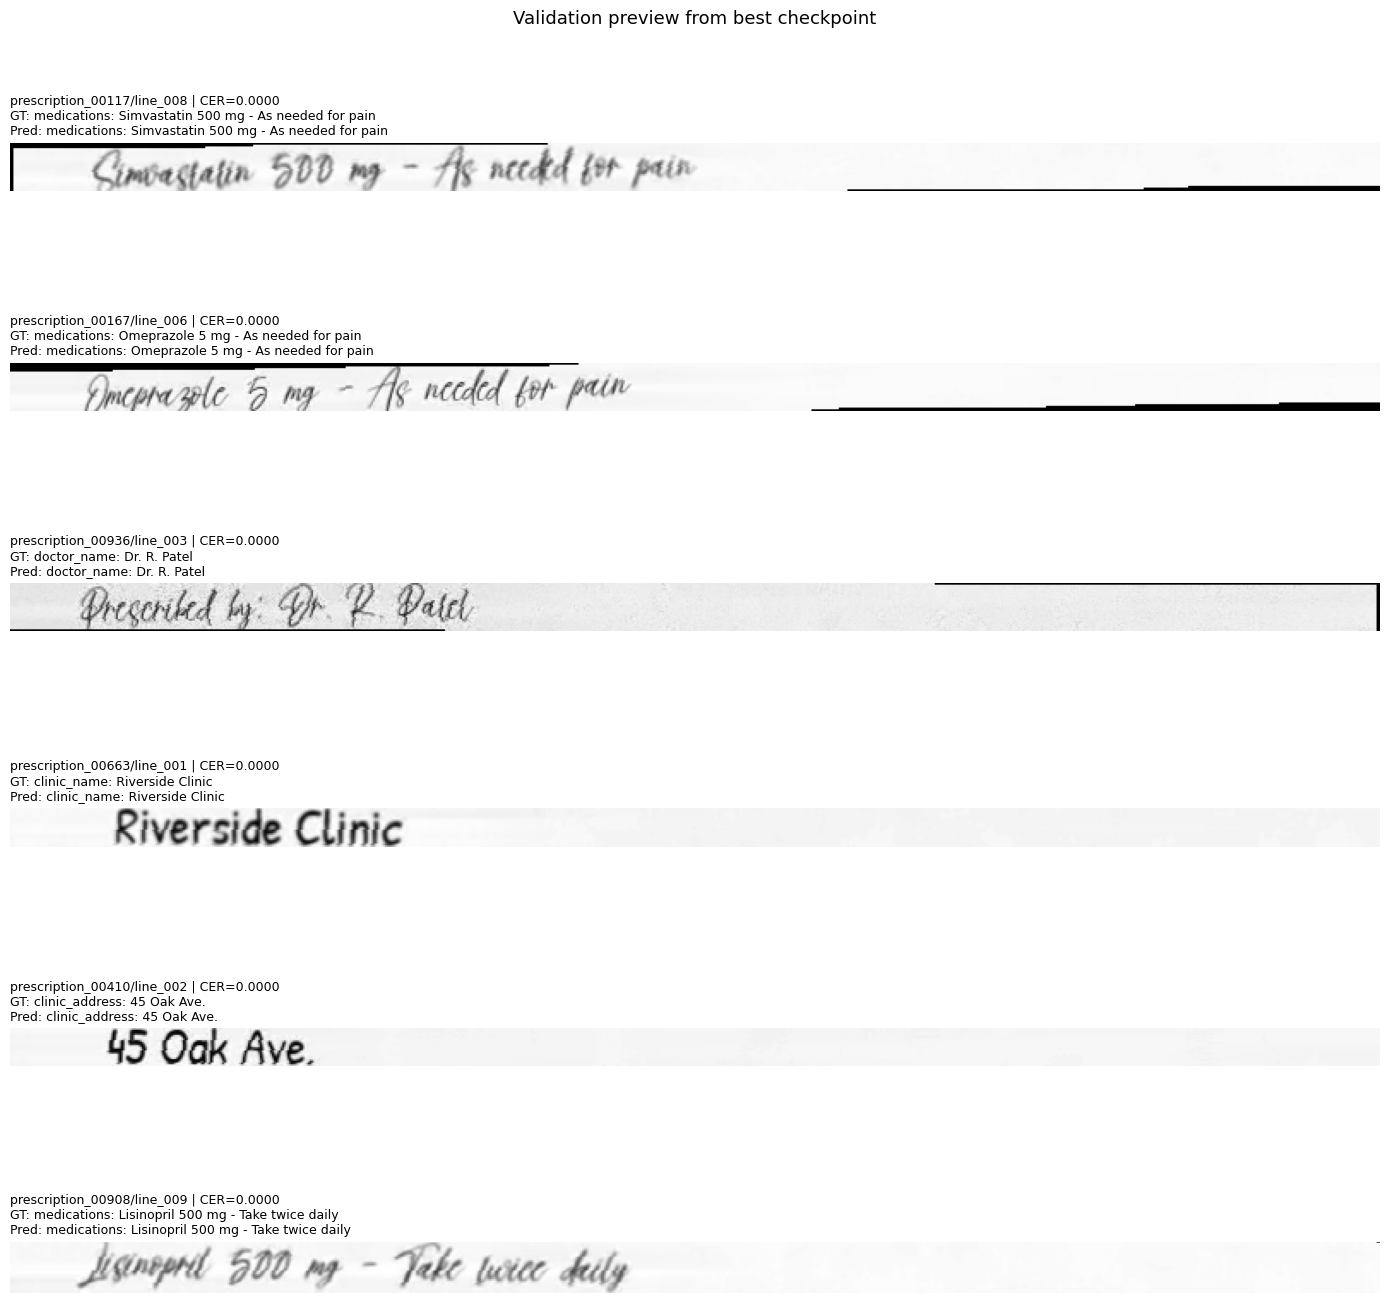

Test inference:   0%|          | 0/105 [00:00<?, ?it/s]

════════════════════════════════════════════════════════════
Test line CER                : 0.0184
Test line word accuracy      : 0.9756
Test full-prescription CER   : 0.0128
Test full-prescription WAcc  : 0.9865
Best validation CER epoch    : 4
Best validation CER value    : 0.0056
════════════════════════════════════════════════════════════


In [32]:
unwrap_model(ocr).to('cpu')
del ocr
if torch.cuda.is_available():
    torch.cuda.empty_cache()

best_model = PrescriptionOCR.load(BEST_MODEL_DIR).to(device)
best_model.eval()

validation_preview = random.sample(val_samples, min(6, len(val_samples)))
if validation_preview:
    fig, axes = plt.subplots(len(validation_preview), 1, figsize=(14, max(3, 2.4 * len(validation_preview))))
    if len(validation_preview) == 1:
        axes = [axes]

    for ax, sample in zip(axes, validation_preview):
        image = Image.open(sample['image_path']).convert('RGB')
        pixel_values = best_model.processor(images=image, return_tensors='pt').pixel_values.to(device)
        with torch.no_grad():
            prediction = best_model.generate(pixel_values, num_beams=FINAL_EVAL_NUM_BEAMS)[0]
        reference = sample['text']
        sample_cer = compute_cer([prediction], [reference])
        ax.imshow(np.array(image))
        ax.set_title(
            f"{sample['origin_id']} | CER={format_metric(sample_cer)}\nGT: {reference[:120]}\nPred: {prediction[:120]}",
            loc='left',
            fontsize=9,
        )
        ax.axis('off')

    plt.suptitle('Validation preview from best checkpoint', fontsize=13)
    plt.tight_layout()
    plt.show()
else:
    print('No validation preview available because the validation split is empty.')

test_predictions, test_references = decode_loader(
    best_model,
    test_loader,
    processor,
    device,
    desc='Test inference',
    num_beams=FINAL_EVAL_NUM_BEAMS,
)
test_line_cer = compute_cer(test_predictions, test_references)
test_line_word_accuracy = compute_word_accuracy(test_predictions, test_references)

by_prescription_prediction = defaultdict(list)
by_prescription_reference = defaultdict(list)
for sample, prediction, reference in zip(test_samples, test_predictions, test_references):
    by_prescription_prediction[sample['prescription_id']].append((sample['origin_id'], prediction))
    by_prescription_reference[sample['prescription_id']].append((sample['origin_id'], reference))

ordered_prescriptions = sorted(by_prescription_prediction)
full_predictions = []
full_references = []
for prescription_id in ordered_prescriptions:
    pred_lines = [text for _, text in sorted(by_prescription_prediction[prescription_id], key=lambda item: item[0])]
    ref_lines = [text for _, text in sorted(by_prescription_reference[prescription_id], key=lambda item: item[0])]
    full_predictions.append(' '.join(pred_lines))
    full_references.append(' '.join(ref_lines))

test_full_cer = compute_cer(full_predictions, full_references)
test_full_word_accuracy = compute_word_accuracy(full_predictions, full_references)

print('═' * 60)
print(f'Test line CER                : {format_metric(test_line_cer)}')
print(f'Test line word accuracy      : {format_metric(test_line_word_accuracy)}')
print(f'Test full-prescription CER   : {format_metric(test_full_cer)}')
print(f'Test full-prescription WAcc  : {format_metric(test_full_word_accuracy)}')
print(f'Best validation CER epoch    : {best_epoch}')
print(f'Best validation CER value    : {format_metric(None if best_cer == float("inf") else best_cer)}')
print('═' * 60)

run_summary = {
    'train_model_name': TRAIN_MODEL_NAME,
    'splits_root': str(SPLITS_ROOT),
    'epochs': TRAIN_EPOCHS,
    'learning_rate': LEARNING_RATE,
    'weight_decay': WEIGHT_DECAY,
    'gpu_count': torch.cuda.device_count(),
    'effective_batch_size': effective_batch_size,
    'validation_num_beams': VALIDATION_NUM_BEAMS,
    'final_eval_num_beams': FINAL_EVAL_NUM_BEAMS,
    'train_lines': len(train_samples),
    'val_lines': len(val_samples),
    'test_lines': len(test_samples),
    'best_epoch': best_epoch,
    'best_val_cer': None if best_cer == float('inf') else float(best_cer),
    'test_line_cer': None if math.isnan(test_line_cer) else float(test_line_cer),
    'test_line_word_accuracy': None if math.isnan(test_line_word_accuracy) else float(test_line_word_accuracy),
    'test_full_cer': None if math.isnan(test_full_cer) else float(test_full_cer),
    'test_full_word_accuracy': None if math.isnan(test_full_word_accuracy) else float(test_full_word_accuracy),
    'splits_drive_file_id': SPLITS_DRIVE_FILE_ID,
}

## 9. Save The Best Model As Kaggle Output

The folder is saved in plain Hugging Face format and zipped so it survives as
a clean notebook artifact in Kaggle outputs.

In [33]:
best_model.save(BEST_MODEL_DIR)

summary_path = BEST_MODEL_DIR / 'training_summary.json'
summary_path.write_text(json.dumps(run_summary, indent=2), encoding='utf-8')

readme_path = BEST_MODEL_DIR / 'README.md'
readme_path.write_text(build_model_card(run_summary), encoding='utf-8')

zip_path = ARTIFACT_DIR / 'medical-prescription-ocr-best-model.zip'
zip_directory(BEST_MODEL_DIR, zip_path)

print(f'Best model folder : {BEST_MODEL_DIR}')
print(f'Model zip artifact: {zip_path}')
print('When you click Save Version in Kaggle, this artifact is preserved in the notebook output.')
print('Saved files:', sorted(path.name for path in BEST_MODEL_DIR.iterdir()))

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Best model folder : /kaggle/working/checkpoints/best_model
Model zip artifact: /kaggle/working/artifacts/medical-prescription-ocr-best-model.zip
When you click Save Version in Kaggle, this artifact is preserved in the notebook output.
Saved files: ['README.md', 'config.json', 'generation_config.json', 'model.safetensors', 'processor_config.json', 'tokenizer.json', 'tokenizer_config.json', 'training_summary.json']


## 10. Optional Hugging Face Upload

This is the easiest way to get a stable model URL. Add a Kaggle secret named
`HF_TOKEN`, set `HF_REPO_ID`, then run the cell below.

In [34]:
user_secrets = UserSecretsClient() if UserSecretsClient is not None else None
secret_value_0 = user_secrets.get_secret('HF_TOKEN') if user_secrets is not None else os.getenv('HF_TOKEN')
model_url = None

if not HF_REPO_ID:
    print('Skipping upload because HF_REPO_ID is empty.')
elif not secret_value_0:
    print('Skipping upload because the HF_TOKEN secret was not found.')
else:
    try:
        login(token=secret_value_0, add_to_git_credential=False)
        upload_folder(
            folder_path=str(BEST_MODEL_DIR),
            repo_id=HF_REPO_ID,
            repo_type='model',
            commit_message='Upload fine-tuned TrOCR checkpoint from Kaggle',
        )
        model_url = f'https://huggingface.co/{HF_REPO_ID}'
        print(f'Uploaded successfully: {model_url}')
    except Exception as exc:
        print(f'Upload failed: {exc}')
        print('Common fixes:')
        print('- Make sure the Kaggle secret name is exactly HF_TOKEN.')
        print('- Use a Hugging Face token with write access to khedim/Medical-Prescription-OCR.')
        print('- If the token is fine-grained, grant write access to that model repo specifically.')
        print(f'Your Kaggle artifact is still available at: {zip_path}')


Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

Uploaded successfully: https://huggingface.co/khedim/Medical-Prescription-OCR
